# Customer Segmentation using K-Means Clustering

**Objective:** Group mall customers into distinct segments based on Age, Annual Income, and Spending Score using unsupervised machine learning.

**Techniques used:**
- K-Means Clustering (K-Means++)
- Elbow Method to find optimal K
- Silhouette Score for evaluation
- PCA for 2D visualization

**Dataset:** Mall Customers Dataset (200 samples, 5 features)

---

## Step 1 — Import Libraries

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2 — Load Dataset

We use the **Mall Customers Dataset**


In [19]:
df = pd.read_csv('Mall_Customers.csv')
df.rename(columns={'Annual Income (k$)': 'Annual_Income_k', 'Spending Score (1-100)': 'Spending_Score'}, inplace=True)

print(f'Dataset shape: {df.shape}')
df.head(10)

Dataset shape: (200, 5)


,CustomerID,Gender,Age,Annual_Income_k,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


## Step 3 — Exploratory Data Analysis (EDA)

In [20]:
df.describe().round(2)

,CustomerID,Age,Annual_Income_k,Spending_Score
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


In [22]:
print('Null values per column:')
print(df.isnull().sum())
print(f'\nGender distribution:')
print(df['Gender'].value_counts())

Null values per column:
CustomerID         0
Gender             0
Age                0
Annual_Income_k    0
Spending_Score     0
dtype: int64

Gender distribution:
Gender
Female    112
Male       88
Name: count, dtype: int64


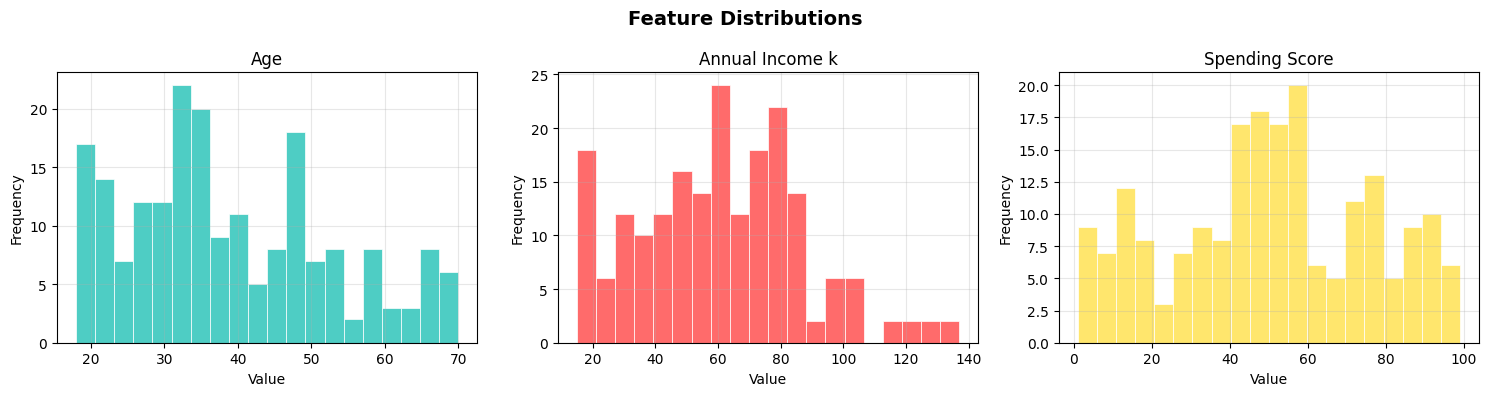

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Feature Distributions', fontsize=14, fontweight='bold')

cols = ['Age', 'Annual_Income_k', 'Spending_Score']
colors = ['#4ECDC4', '#FF6B6B', '#FFE66D']

for ax, col, color in zip(axes, cols, colors):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', linewidth=0.5)
    ax.set_title(col.replace('_', ' '))
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

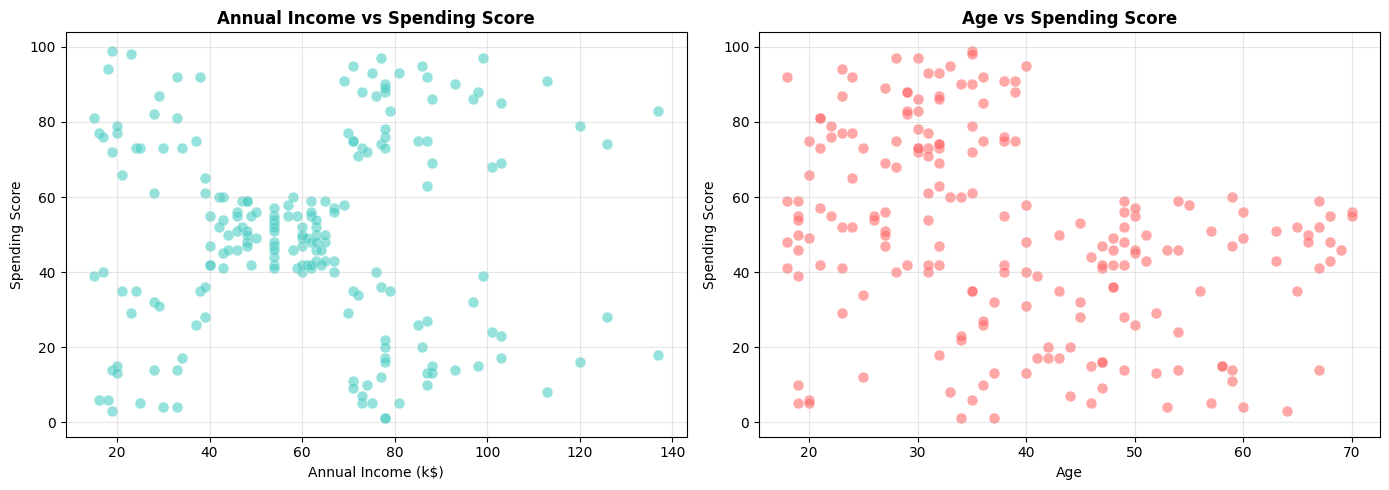

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['Annual_Income_k'], df['Spending_Score'],
                alpha=0.6, color='#4ECDC4', edgecolors='white', linewidth=0.3, s=60)
axes[0].set_title('Annual Income vs Spending Score', fontweight='bold')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score')
axes[0].grid(alpha=0.3)

axes[1].scatter(df['Age'], df['Spending_Score'],
                alpha=0.6, color='#FF6B6B', edgecolors='white', linewidth=0.3, s=60)
axes[1].set_title('Age vs Spending Score', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Spending Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Top right → high income, high spending
#### Top left → low income, high spending
#### Bottom right → high income, low spending
#### Bottom left → low income, low spending
#### Middle → average everything

## Step 4 — Data Preprocessing

We select the 3 numeric features and apply **StandardScaler** so no single feature dominates due to scale differences.

In [25]:
features = ['Age', 'Annual_Income_k', 'Spending_Score']
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Before scaling (first 3 rows):')
print(X.head(3).to_string())
print('\nAfter scaling (first 3 rows):')
print(pd.DataFrame(X_scaled[:3], columns=features).round(3).to_string())
print('\nFeatures scaled using StandardScaler.')

Before scaling (first 3 rows):
   Age  Annual_Income_k  Spending_Score
0   19               15              39
1   21               15              81
2   20               16               6

After scaling (first 3 rows):
     Age  Annual_Income_k  Spending_Score
0 -1.425           -1.739          -0.435
1 -1.281           -1.739           1.196
2 -1.353           -1.701          -1.716

Features scaled using StandardScaler.


## Step 5 — Find Optimal K (Elbow Method + Silhouette Score)

- **Elbow Method:** Plot inertia (WCSS) vs K — pick the point where the curve bends
- **Silhouette Score:** How well-separated are the clusters (closer to 1.0 = better)

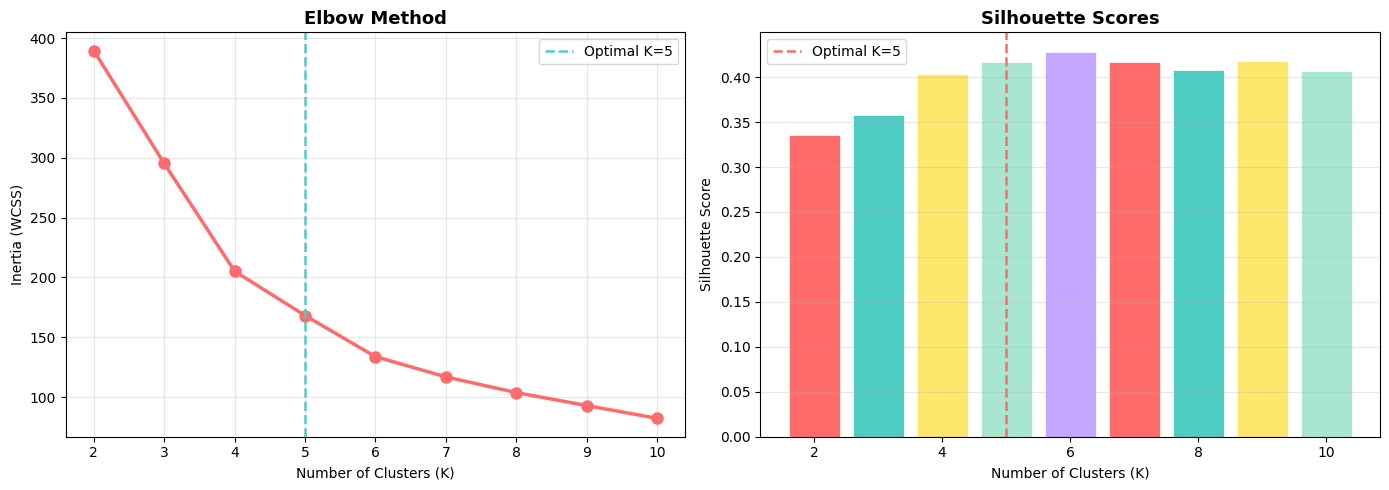

K        Inertia   Silhouette
------------------------------
K=2        389.4       0.3355
K=3        295.2       0.3578
K=4        205.2       0.4040
K=5        168.2       0.4166 <- optimal
K=6        133.9       0.4284
K=7        117.0       0.4172
K=8        103.9       0.4082
K=9         93.1       0.4177
K=10        82.4       0.4066


In [26]:
inertia = []
silhouette = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertia, 'o-', color='#FF6B6B', linewidth=2.5, markersize=8)
axes[0].axvline(x=5, color='#4ECDC4', linestyle='--', linewidth=1.8, label='Optimal K=5')
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].legend()
axes[0].grid(alpha=0.3)

bar_colors = ['#FF6B6B','#4ECDC4','#FFE66D','#A8E6CF','#C3A6FF','#FF6B6B','#4ECDC4','#FFE66D','#A8E6CF']
axes[1].bar(list(K_range), silhouette, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[1].axvline(x=5, color='#FF6B6B', linestyle='--', linewidth=1.8, label='Optimal K=5')
axes[1].set_title('Silhouette Scores', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f'{"K":<5} {"Inertia":>10} {"Silhouette":>12}')
print('-' * 30)
for k, inr, sil in zip(K_range, inertia, silhouette):
    marker = ' <- optimal' if k == 5 else ''
    print(f'K={k:<3} {inr:>10.1f} {sil:>12.4f}{marker}')

## Step 6 — Train Final K-Means Model (K=5)

In [27]:
OPTIMAL_K = 5
kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

score = silhouette_score(X_scaled, df['Cluster'])
print(f'Model trained with K={OPTIMAL_K}')
print(f'Silhouette Score : {score:.4f}')
print(f'Inertia          : {kmeans.inertia_:.2f}')

print('\nCluster Profiles (mean values):')
profile = df.groupby('Cluster')[features].mean().round(1)
profile['Count'] = df['Cluster'].value_counts().sort_index()
profile

Model trained with K=5
Silhouette Score : 0.4166
Inertia          : 168.25

Cluster Profiles (mean values):


,Age,Annual_Income_k,Spending_Score,Count
Cluster,,,,
0,46.2,26.8,18.4,20
1,25.2,41.1,62.2,54
2,32.9,86.1,81.5,40
3,39.9,86.1,19.4,39
4,55.6,54.4,48.9,47


## Step 7 — Visualize Clusters

In [28]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

print(f'Total PCA Explained Variance : {pca.explained_variance_ratio_.sum()*100:.1f}%')
print(f'  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%')

Total PCA Explained Variance : 77.6%
  PC1: 44.3%
  PC2: 33.3%


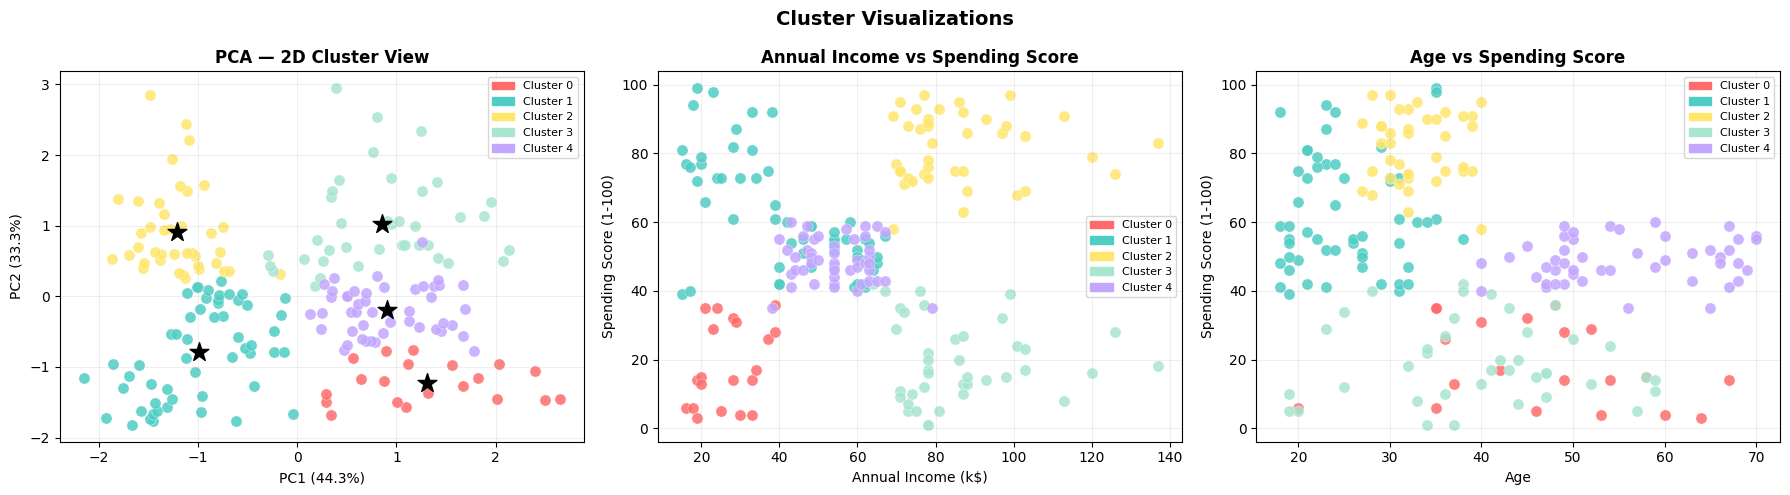

In [29]:
COLORS = ['#FF6B6B', '#4ECDC4', '#FFE66D', '#A8E6CF', '#C3A6FF']
patches = [mpatches.Patch(color=COLORS[i], label=f'Cluster {i}') for i in range(OPTIMAL_K)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Cluster Visualizations', fontsize=14, fontweight='bold')

# PCA scatter
for i in range(OPTIMAL_K):
    mask = df['Cluster'] == i
    axes[0].scatter(df.loc[mask, 'PCA1'], df.loc[mask, 'PCA2'],
                    c=COLORS[i], s=65, alpha=0.85, edgecolors='white', linewidth=0.3)
centers_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centers_pca[:, 0], centers_pca[:, 1],
                c='black', s=200, marker='*', zorder=5)
axes[0].set_title('PCA — 2D Cluster View', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(handles=patches, fontsize=8)
axes[0].grid(alpha=0.2)

# Income vs Spending
for i in range(OPTIMAL_K):
    mask = df['Cluster'] == i
    axes[1].scatter(df.loc[mask, 'Annual_Income_k'], df.loc[mask, 'Spending_Score'],
                    c=COLORS[i], s=65, alpha=0.85, edgecolors='white', linewidth=0.3)
axes[1].set_title('Annual Income vs Spending Score', fontweight='bold')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')
axes[1].legend(handles=patches, fontsize=8)
axes[1].grid(alpha=0.2)

# Age vs Spending
for i in range(OPTIMAL_K):
    mask = df['Cluster'] == i
    axes[2].scatter(df.loc[mask, 'Age'], df.loc[mask, 'Spending_Score'],
                    c=COLORS[i], s=65, alpha=0.85, edgecolors='white', linewidth=0.3)
axes[2].set_title('Age vs Spending Score', fontweight='bold')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Spending Score (1-100)')
axes[2].legend(handles=patches, fontsize=8)
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.show()

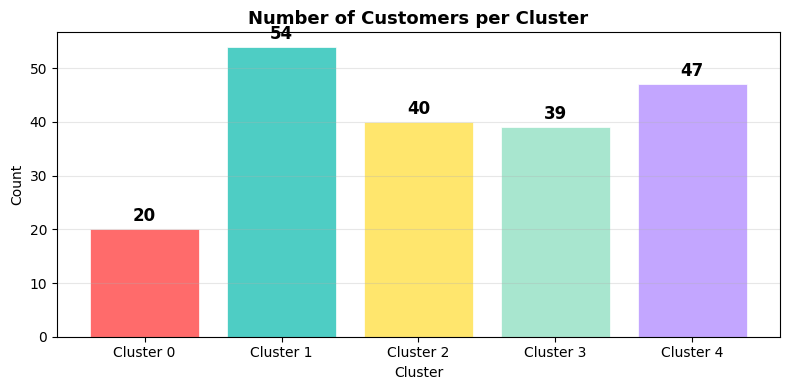

In [30]:
fig, ax = plt.subplots(figsize=(8, 4))
cluster_counts = df['Cluster'].value_counts().sort_index()
bars = ax.bar([f'Cluster {i}' for i in cluster_counts.index],
              cluster_counts.values, color=COLORS, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, cluster_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Number of Customers per Cluster', fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Count')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Step 8 — Business Insights

Based on the cluster profiles, we label and interpret each segment:

In [31]:
profile = df.groupby('Cluster')[['Age', 'Annual_Income_k', 'Spending_Score']].mean().round(1)
profile['Count'] = df['Cluster'].value_counts().sort_index()

def label_segment(row):
    if row['Annual_Income_k'] > 80 and row['Spending_Score'] > 60:
        return 'High Income, High Spenders (VIP)'
    elif row['Annual_Income_k'] > 80 and row['Spending_Score'] <= 60:
        return 'High Income, Low Spenders'
    elif row['Age'] < 35 and row['Spending_Score'] > 60:
        return 'Young, High Spenders'
    elif row['Annual_Income_k'] < 45 and row['Spending_Score'] < 45:
        return 'Low Income, Low Spenders'
    else:
        return 'Average Customers'

profile['Segment'] = profile.apply(label_segment, axis=1)
print('Customer Segment Profiles:')
print(profile.to_string())

print('\nMarketing Recommendations:')
print('=' * 60)
tips = [
    ('High Income, High Spenders (VIP)', 'Loyalty programs, exclusive deals, early access.'),
    ('High Income, Low Spenders',        'Premium product campaigns to increase engagement.'),
    ('Young, High Spenders',             'Social media targeting, flash sales, trend content.'),
    ('Low Income, Low Spenders',         'Discounts, value bundles, budget-friendly offers.'),
    ('Average Customers',                'Personalized recommendations to increase spend.'),
]
for seg, tip in tips:
    print(f'\n  {seg}')
    print(f'    -> {tip}')

Customer Segment Profiles:
          Age  Annual_Income_k  Spending_Score  Count                           Segment
Cluster                                                                                
0        46.2             26.8            18.4     20          Low Income, Low Spenders
1        25.2             41.1            62.2     54              Young, High Spenders
2        32.9             86.1            81.5     40  High Income, High Spenders (VIP)
3        39.9             86.1            19.4     39         High Income, Low Spenders
4        55.6             54.4            48.9     47                 Average Customers

Marketing Recommendations:

  High Income, High Spenders (VIP)
    -> Loyalty programs, exclusive deals, early access.

  High Income, Low Spenders
    -> Premium product campaigns to increase engagement.

  Young, High Spenders
    -> Social media targeting, flash sales, trend content.

  Low Income, Low Spenders
    -> Discounts, value bundles, budget-